# Práctico 2 — Manipulación de tablas y series de tiempo
### Curso: Análisis de Datos
**Integrantes:** 

## 1. Obtención de los datos

In [98]:
import pandas as pd

### a. Cargar los datos

In [99]:
df = pd.read_csv('starbucks.csv')
df

,Store Number,Store Name,Address,City
0,10429-100710,Palmdale & Hwy 395,14136 US Hwy 395 Adelanto CA,Adelanto
1,635-352,Kanan & Thousand Oaks,5827 Kanan Road Agoura CA,Agoura
2,74510-27669,Vons-Agoura Hills #2001,5671 Kanan Rd. Agoura Hills CA,Agoura Hills
3,29839-255026,Target Anaheim T-0677,8148 E SANTA ANA CANYON ROAD AHAHEIM CA,AHAHEIM
4,23463-230284,Safeway - Alameda 3281,2600 5th Street Alameda CA,Alameda
...,...,...,...,...
2816,14071-108147,Hwy 20 & Tharp - Yuba City,"1615 Colusa Hwy, Ste 100 Yuba City CA",Yuba City
2817,9974-98559,"Yucaipa & Hampton, Yucaipa","31364 Yucaipa Blvd., A Yucaipa CA",Yucaipa
2818,79654-108478,Vons - Yucaipa #1796,33644 YUCAIPA BLVD YUCAIPA CA,YUCAIPA
2819,6438-245084,Yucaipa & 6th,"34050 Yucaipa Blvd., 200 Yucaipa CA",Yucaipa


### b. Resumen y explicación de variables

El dataset contiene registros de tiendas de Starbucks en California, Estados Unidos. Sus columnas son:

| Variable | Tipo | Descripción |
|---|---|---|
| `Store Number` | string | Identificador único de cada tienda (formato `id1-id2`) |
| `Store Name` | string | Nombre comercial de la tienda |
| `Address` | string | Dirección completa incluyendo número, calle, ciudad y estado |
| `City` | string | Ciudad donde se ubica la tienda |

In [100]:
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: 2821 filas x 4 columnas

Tipos de datos:
Store Number    object
Store Name      object
Address         object
City            object
dtype: object

Valores nulos por columna:
Store Number    0
Store Name      0
Address         0
City            0
dtype: int64


### c. Primeros datos

In [101]:
df.head()

,Store Number,Store Name,Address,City
0,10429-100710,Palmdale & Hwy 395,14136 US Hwy 395 Adelanto CA,Adelanto
1,635-352,Kanan & Thousand Oaks,5827 Kanan Road Agoura CA,Agoura
2,74510-27669,Vons-Agoura Hills #2001,5671 Kanan Rd. Agoura Hills CA,Agoura Hills
3,29839-255026,Target Anaheim T-0677,8148 E SANTA ANA CANYON ROAD AHAHEIM CA,AHAHEIM
4,23463-230284,Safeway - Alameda 3281,2600 5th Street Alameda CA,Alameda


---
## 3. Manejo de series de tiempo

In [102]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

### a. Cargar archivos CSV en dos dataframes

In [103]:
df_2023 = pd.read_csv('inumet_temperatura-del-aire-2023.csv')
df_2024 = pd.read_csv('inumet_temperatura-del-aire-2024.csv')

df_2023['fecha'] = pd.to_datetime(df_2023['fecha'], utc=True)
df_2024['fecha'] = pd.to_datetime(df_2024['fecha'], utc=True)
df_2023['TempAire'] = pd.to_numeric(df_2023['TempAire'], errors='coerce')
df_2024['TempAire'] = pd.to_numeric(df_2024['TempAire'], errors='coerce')

print("2023:", df_2023.shape)
print(df_2023.head(3))
print("\n2024:", df_2024.shape)
print(df_2024.head(3))

2023: (17520, 3)
                      fecha       estacion_idStr  TempAire
0 2023-01-01 00:00:00+00:00             CARRASCO      20.6
1 2023-01-01 00:00:00+00:00  aeropuertomelillag3      20.0
2 2023-01-01 01:00:00+00:00             CARRASCO      20.5

2024: (3839, 3)
                      fecha       estacion_idStr  TempAire
0 2024-01-01 00:00:00+00:00             CARRASCO      21.9
1 2024-01-01 00:00:00+00:00  aeropuertomelillag3      20.2
2 2024-01-01 01:00:00+00:00             CARRASCO      21.3


### b. Unir ambos dataframes en una sola tabla

In [104]:
df_temp = pd.concat([df_2023, df_2024], ignore_index=True)
df_temp = df_temp.sort_values('fecha').reset_index(drop=True)

print(f"Total de registros: {df_temp.shape[0]}")
print(f"Período: {df_temp['fecha'].min()} → {df_temp['fecha'].max()}")
print(f"Estaciones: {df_temp['estacion_idStr'].unique()}")
df_temp.head()

Total de registros: 21359
Período: 2023-01-01 00:00:00+00:00 → 2024-03-20 23:00:00+00:00
Estaciones: ['CARRASCO' 'aeropuertomelillag3']


,fecha,estacion_idStr,TempAire
0,2023-01-01 00:00:00+00:00,CARRASCO,20.6
1,2023-01-01 00:00:00+00:00,aeropuertomelillag3,20.0
2,2023-01-01 01:00:00+00:00,CARRASCO,20.5
3,2023-01-01 01:00:00+00:00,aeropuertomelillag3,20.0
4,2023-01-01 02:00:00+00:00,CARRASCO,20.3


### c. Graficar el comportamiento de la temperatura en función del tiempo

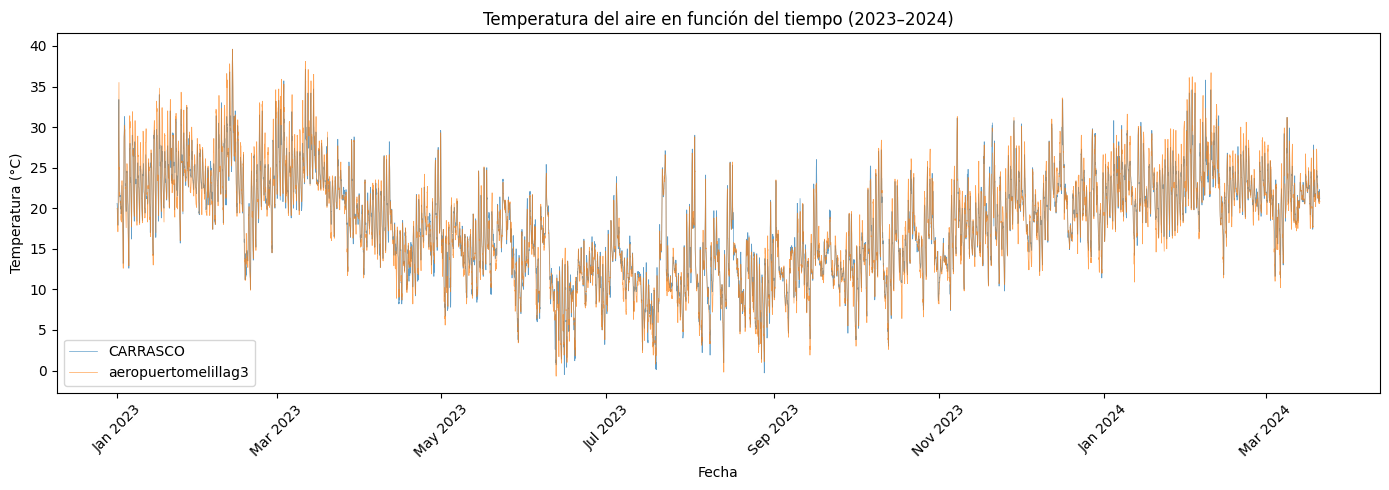

In [105]:
fig, ax = plt.subplots(figsize=(14, 5))

for estacion, grupo in df_temp.groupby('estacion_idStr'):
    ax.plot(grupo['fecha'], grupo['TempAire'], linewidth=0.5, alpha=0.7, label=estacion)

ax.set_title('Temperatura del aire en función del tiempo (2023–2024)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### d. Crear un filtro para poder ver mejor las tendencias

Se aplica una media móvil de 7 días (ventana de 168 registros horarios) para suavizar las fluctuaciones diarias y visualizar mejor la tendencia de largo plazo.

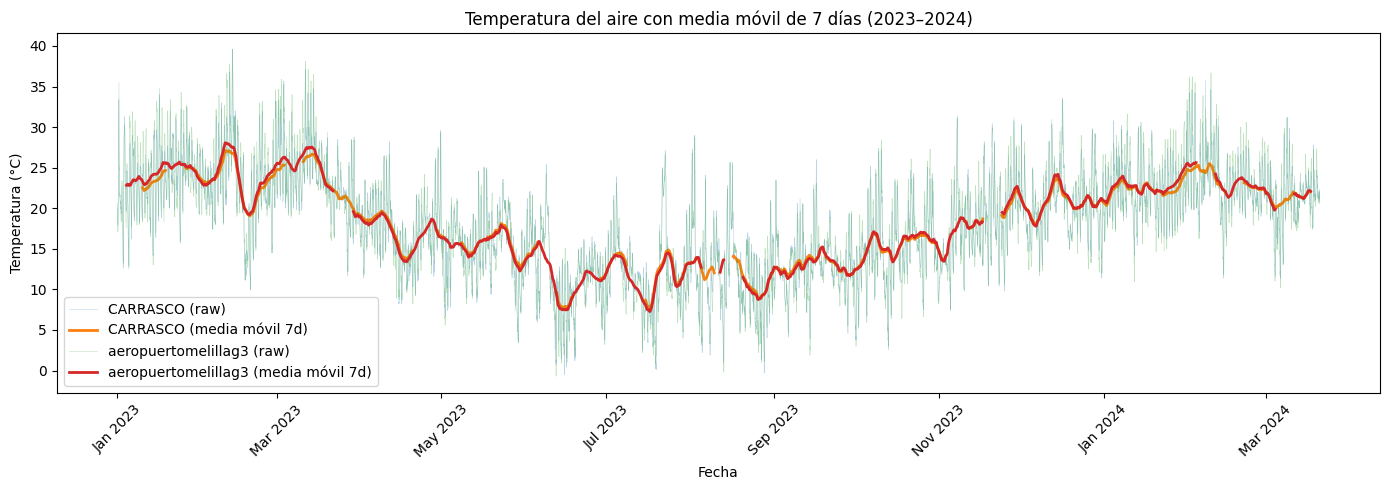

In [106]:
VENTANA = 24 * 7  # media móvil de 7 días

fig, ax = plt.subplots(figsize=(14, 5))

for estacion, grupo in df_temp.groupby('estacion_idStr'):
    grupo = grupo.sort_values('fecha')
    media_movil = grupo['TempAire'].rolling(window=VENTANA, center=True).mean()
    ax.plot(grupo['fecha'], grupo['TempAire'], linewidth=0.4, alpha=0.3, label=f'{estacion} (raw)')
    ax.plot(grupo['fecha'], media_movil, linewidth=2, label=f'{estacion} (media móvil 7d)')

ax.set_title('Temperatura del aire con media móvil de 7 días (2023–2024)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### e. Graficar la temperatura para distintos períodos de tiempo

Se analizan distintos recortes temporales para identificar tendencias estacionales, cambios entre años y posibles valores anómalos.

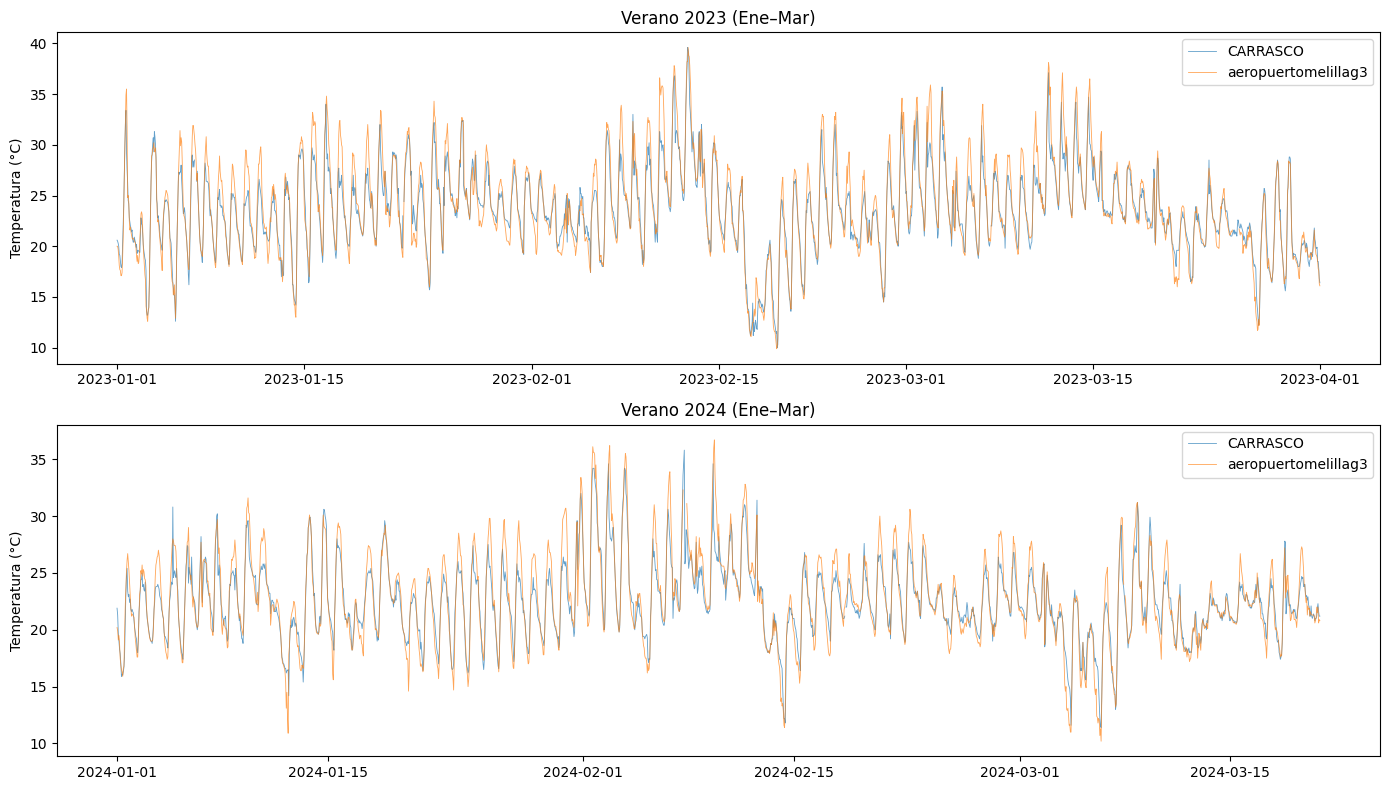

In [107]:
# --- Verano 2023 (enero–marzo) vs Verano 2024 (enero–marzo) ---
verano_2023 = df_temp[(df_temp['fecha'] >= '2023-01-01') & (df_temp['fecha'] < '2023-04-01')]
verano_2024 = df_temp[(df_temp['fecha'] >= '2024-01-01') & (df_temp['fecha'] < '2024-04-01')]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for estacion, grupo in verano_2023.groupby('estacion_idStr'):
    axes[0].plot(grupo['fecha'], grupo['TempAire'], linewidth=0.6, alpha=0.7, label=estacion)
axes[0].set_title('Verano 2023 (Ene–Mar)')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()

for estacion, grupo in verano_2024.groupby('estacion_idStr'):
    axes[1].plot(grupo['fecha'], grupo['TempAire'], linewidth=0.6, alpha=0.7, label=estacion)
axes[1].set_title('Verano 2024 (Ene–Mar)')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

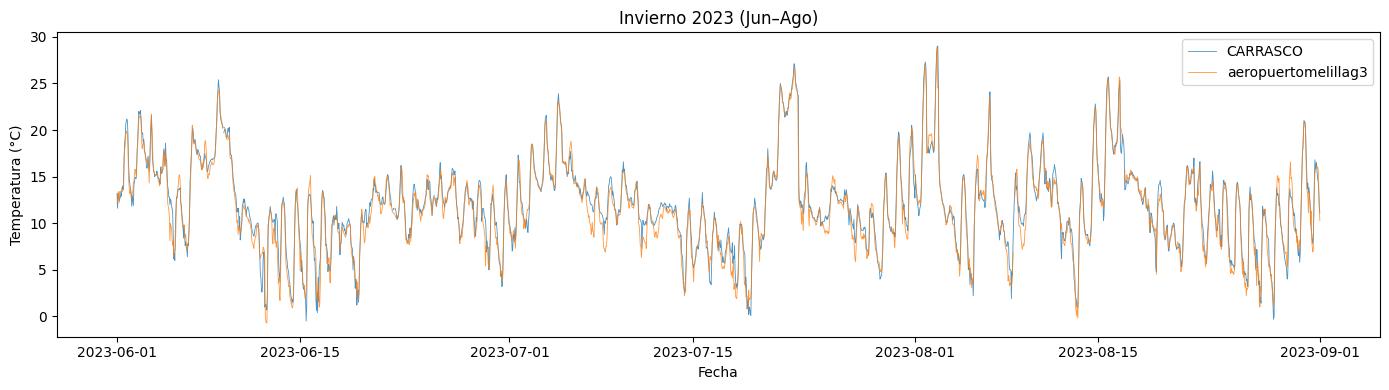

In [108]:
# --- Invierno 2023 (junio–agosto) ---
invierno_2023 = df_temp[(df_temp['fecha'] >= '2023-06-01') & (df_temp['fecha'] < '2023-09-01')]

fig, ax = plt.subplots(figsize=(14, 4))
for estacion, grupo in invierno_2023.groupby('estacion_idStr'):
    ax.plot(grupo['fecha'], grupo['TempAire'], linewidth=0.6, alpha=0.8, label=estacion)
ax.set_title('Invierno 2023 (Jun–Ago)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()

Media: 18.16 °C  |  Desv. estándar: 6.27 °C
Valores anómalos encontrados: 18
                         fecha       estacion_idStr  TempAire
2000 2023-02-11 16:00:00+00:00  aeropuertomelillag3      37.8
2003 2023-02-11 17:00:00+00:00  aeropuertomelillag3      37.5
2046 2023-02-12 15:00:00+00:00             CARRASCO      37.5
2047 2023-02-12 15:00:00+00:00  aeropuertomelillag3      38.2
2048 2023-02-12 16:00:00+00:00             CARRASCO      39.6
2049 2023-02-12 16:00:00+00:00  aeropuertomelillag3      38.2
2050 2023-02-12 17:00:00+00:00             CARRASCO      39.4
2051 2023-02-12 17:00:00+00:00  aeropuertomelillag3      39.6
2052 2023-02-12 18:00:00+00:00  aeropuertomelillag3      38.8
2053 2023-02-12 18:00:00+00:00             CARRASCO      39.0
2055 2023-02-12 19:00:00+00:00  aeropuertomelillag3      38.7
2057 2023-02-12 20:00:00+00:00  aeropuertomelillag3      37.8
3344 2023-03-11 16:00:00+00:00  aeropuertomelillag3      38.1
3345 2023-03-11 16:00:00+00:00             CARRASCO    

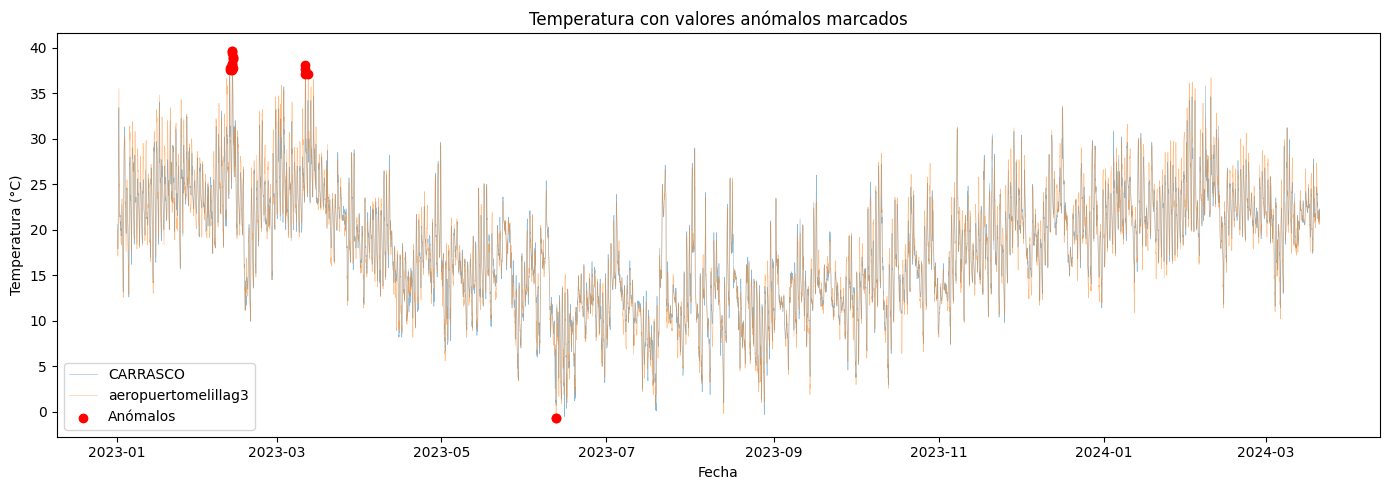

In [109]:
# --- Detección de valores anómalos (fuera de media ± 3 desvíos estándar) ---
media = df_temp['TempAire'].mean()
std   = df_temp['TempAire'].std()
anomalos = df_temp[(df_temp['TempAire'] > media + 3*std) | (df_temp['TempAire'] < media - 3*std)]

print(f"Media: {media:.2f} °C  |  Desv. estándar: {std:.2f} °C")
print(f"Valores anómalos encontrados: {len(anomalos)}")
print(anomalos[['fecha','estacion_idStr','TempAire']])

fig, ax = plt.subplots(figsize=(14, 5))
for estacion, grupo in df_temp.groupby('estacion_idStr'):
    ax.plot(grupo['fecha'], grupo['TempAire'], linewidth=0.4, alpha=0.5, label=estacion)
ax.scatter(anomalos['fecha'], anomalos['TempAire'], color='red', zorder=5, label='Anómalos')
ax.set_title('Temperatura con valores anómalos marcados')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### f. Para los datos del último año, crear filas con hora = punto medio entre dos observaciones

El último año disponible es 2024. Se insertan filas con timestamps intermedios (30 minutos después de cada observación) entre cada par de registros consecutivos, por estación.

In [110]:
df_2024_proc = df_temp[df_temp['fecha'].dt.year == 2024].copy()

filas_intermedias = []

for estacion, grupo in df_2024_proc.groupby('estacion_idStr'):
    grupo = grupo.sort_values('fecha').reset_index(drop=True)
    for i in range(len(grupo) - 1):
        t1 = grupo.loc[i, 'fecha']
        t2 = grupo.loc[i + 1, 'fecha']
        t_medio = t1 + (t2 - t1) / 2
        filas_intermedias.append({
            'fecha': t_medio,
            'estacion_idStr': estacion,
            'TempAire': np.nan
        })

df_intermedios = pd.DataFrame(filas_intermedias)
print(f"Filas intermedias creadas: {len(df_intermedios)}")
df_intermedios.head()

Filas intermedias creadas: 3837


,fecha,estacion_idStr,TempAire
0,2024-01-01 00:30:00+00:00,CARRASCO,NaN
1,2024-01-01 01:30:00+00:00,CARRASCO,NaN
2,2024-01-01 02:30:00+00:00,CARRASCO,NaN
3,2024-01-01 03:30:00+00:00,CARRASCO,NaN
4,2024-01-01 04:30:00+00:00,CARRASCO,NaN


### g. Estimar la temperatura en esos puntos e ingresarla en la tabla

Se combina el dataset original de 2024 con las filas intermedias. Luego se aplica interpolación lineal para estimar la temperatura en los puntos intermedios.

In [111]:
df_2024_ampliado_list = []

for estacion, grupo in df_2024_proc.groupby('estacion_idStr'):
    intermedios_est = df_intermedios[df_intermedios['estacion_idStr'] == estacion]
    combinado = pd.concat([grupo, intermedios_est], ignore_index=True)
    combinado = combinado.sort_values('fecha').reset_index(drop=True)
    combinado['TempAire'] = combinado['TempAire'].interpolate(method='linear')
    df_2024_ampliado_list.append(combinado)

df_2024_ampliado = pd.concat(df_2024_ampliado_list, ignore_index=True)
df_2024_ampliado = df_2024_ampliado.sort_values(['fecha', 'estacion_idStr']).reset_index(drop=True)

print(f"Registros originales 2024: {len(df_2024_proc)}")
print(f"Registros con puntos intermedios: {len(df_2024_ampliado)}")
df_2024_ampliado.head(10)

Registros originales 2024: 3839
Registros con puntos intermedios: 7676


,fecha,estacion_idStr,TempAire
0,2024-01-01 00:00:00+00:00,CARRASCO,21.90
1,2024-01-01 00:00:00+00:00,aeropuertomelillag3,20.20
2,2024-01-01 00:30:00+00:00,CARRASCO,21.60
3,2024-01-01 00:30:00+00:00,aeropuertomelillag3,20.05
4,2024-01-01 01:00:00+00:00,CARRASCO,21.30
5,2024-01-01 01:00:00+00:00,aeropuertomelillag3,19.90
6,2024-01-01 01:30:00+00:00,CARRASCO,20.50
7,2024-01-01 01:30:00+00:00,aeropuertomelillag3,19.50
8,2024-01-01 02:00:00+00:00,CARRASCO,19.70
9,2024-01-01 02:00:00+00:00,aeropuertomelillag3,19.10


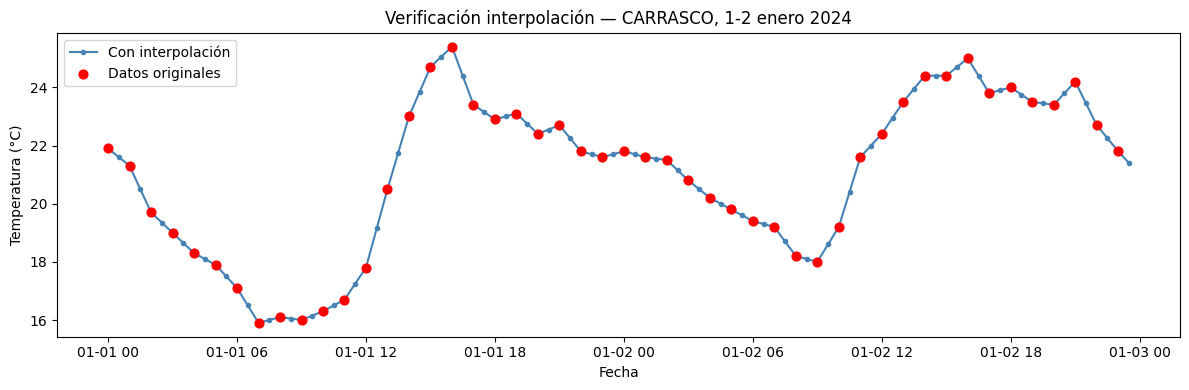

In [112]:
# Verificación visual: comparar datos originales vs interpolados en enero 2024
enero_orig = df_2024_proc[
    (df_2024_proc['fecha'] < '2024-01-03') &
    (df_2024_proc['estacion_idStr'] == 'CARRASCO')
]
enero_amp = df_2024_ampliado[
    (df_2024_ampliado['fecha'] < '2024-01-03') &
    (df_2024_ampliado['estacion_idStr'] == 'CARRASCO')
]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(enero_amp['fecha'], enero_amp['TempAire'], 'o-', markersize=3, label='Con interpolación', color='steelblue')
ax.scatter(enero_orig['fecha'], enero_orig['TempAire'], color='red', zorder=5, s=40, label='Datos originales')
ax.set_title('Verificación interpolación — CARRASCO, 1-2 enero 2024')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()